# Cache hierarchy revealed by a Triton kernel

Reproduces every data slide from the talk on one GPU. Cells are grouped by slide.


In [1]:
import torch
import triton
import triton.language as tl
import numpy as np
import matplotlib.pyplot as plt

assert torch.cuda.is_available(), "needs a CUDA GPU"
device = torch.device("cuda")
props  = torch.cuda.get_device_properties(device)
print(f"GPU: {props.name}  ·  SM{props.major}{props.minor}  ·  L2 = {props.L2_cache_size/1024:.0f} KB"
      if hasattr(props, 'L2_cache_size') else f"GPU: {props.name}  ·  SM{props.major}{props.minor}")
print(f"Triton {triton.__version__}  ·  Torch {torch.__version__}")


GPU: NVIDIA GeForce RTX 3060 Ti  ·  SM86  ·  L2 = 3072 KB
Triton 3.6.0  ·  Torch 2.11.0+cu130


## 1. The Triton kernel


In [2]:
BLOCK       = 1024     # float32s per program iteration
INNER_REPS  = 64       # times each program rereads the buffer

@triton.jit
def reuse_read(x_ptr, out_ptr, N, INNER_REPS: tl.constexpr, BLOCK: tl.constexpr):
    pid = tl.program_id(axis=0)
    s   = tl.zeros([BLOCK], dtype=tl.float32)
    for _ in range(INNER_REPS):
        i = 0
        while i < N:
            offsets = i + tl.arange(0, BLOCK)
            mask    = offsets < N
            x       = tl.load(x_ptr + offsets, mask=mask, other=0.0)
            s       = s + x
            i += BLOCK
    tl.store(out_ptr + pid * BLOCK + tl.arange(0, BLOCK), s)


## 2. Timing helper · CUDA events


In [3]:
NUM_PROGRAMS = props.multi_processor_count * 4   # saturate every SM

def time_at_ws(ws_bytes, reps=20, warmup=5):
    n   = ws_bytes // 4                            # float32 count
    x   = torch.randn(n, device=device, dtype=torch.float32)
    out = torch.empty(NUM_PROGRAMS * BLOCK, device=device, dtype=torch.float32)
    grid = (NUM_PROGRAMS,)

    # warm up · fill whatever caches the WS allows
    for _ in range(warmup):
        reuse_read[grid](x, out, n, INNER_REPS, BLOCK)
    torch.cuda.synchronize()

    # time
    e0 = torch.cuda.Event(enable_timing=True)
    e1 = torch.cuda.Event(enable_timing=True)
    e0.record()
    for _ in range(reps):
        reuse_read[grid](x, out, n, INNER_REPS, BLOCK)
    e1.record()
    torch.cuda.synchronize()
    ms_per_call    = e0.elapsed_time(e1) / reps
    bytes_per_call = NUM_PROGRAMS * n * INNER_REPS * 4
    gbs            = bytes_per_call / (ms_per_call * 1e6)  # ms→s + B→GB
    return ms_per_call, gbs


## 3. Bandwidth sweep across WS (slide R3 · fig_bandwidth_sweep)


In [4]:
ws_kb = [4, 8, 16, 32, 64, 96, 128, 160, 192, 256, 384, 512, 1024,
         2048, 3072, 4096, 6144, 8192, 12288, 16384]

results = {}
for kb in ws_kb:
    ms, gbs = time_at_ws(kb * 1024)
    results[kb] = (ms, gbs)
    print(f"WS = {kb:>6} KB   {ms*1000:>8.2f} µs/call   {gbs:>7.1f} GB/s")


WS =      4 KB      19.81 µs/call    2011.0 GB/s
WS =      8 KB      19.81 µs/call    4021.9 GB/s
WS =     16 KB      31.85 µs/call    5004.8 GB/s
WS =     32 KB      56.32 µs/call    5659.9 GB/s
WS =     64 KB     104.96 µs/call    6074.1 GB/s
WS =     96 KB     153.04 µs/call    6248.8 GB/s
WS =    128 KB     228.44 µs/call    5581.6 GB/s
WS =    160 KB     359.73 µs/call    4430.6 GB/s
WS =    192 KB     422.74 µs/call    4524.3 GB/s
WS =    256 KB     571.03 µs/call    4465.8 GB/s
WS =    384 KB     840.14 µs/call    4553.1 GB/s
WS =    512 KB    1122.15 µs/call    4545.1 GB/s
WS =   1024 KB    2244.15 µs/call    4545.4 GB/s


WS =   2048 KB    4487.42 µs/call    4546.3 GB/s
WS =   3072 KB    7580.31 µs/call    4037.0 GB/s


WS =   4096 KB   12822.54 µs/call    3182.1 GB/s


WS =   6144 KB   19153.60 µs/call    3195.4 GB/s


WS =   8192 KB   25738.24 µs/call    3170.6 GB/s


WS =  12288 KB   38657.02 µs/call    3166.5 GB/s


WS =  16384 KB   51618.57 µs/call    3161.8 GB/s


## 4. Plot · three plateaus (slide R3)


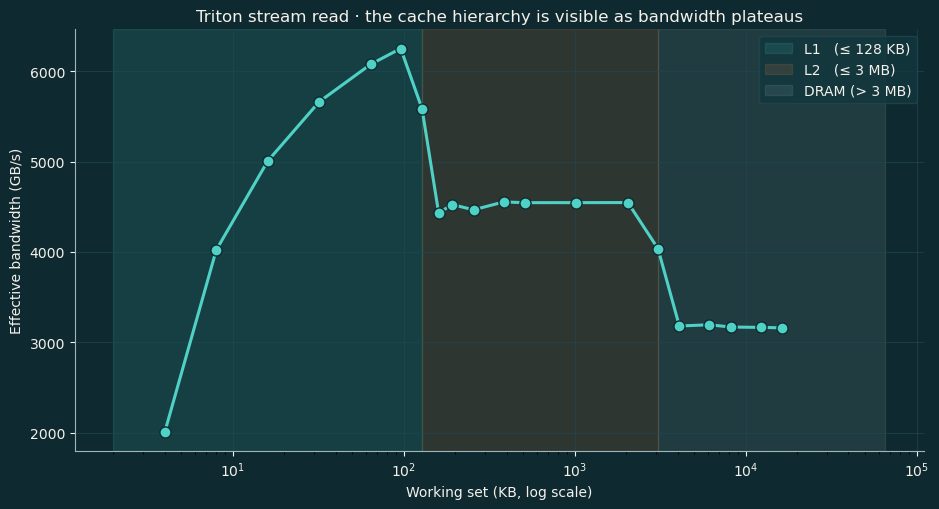

In [5]:
ws  = np.array(list(results.keys()))
gbs = np.array([results[k][1] for k in ws])

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.set_facecolor("#0E2A30"); fig.patch.set_facecolor("#0E2A30")

ax.semilogx(ws, gbs, "o-", color="#4FD1C5", linewidth=2.2, markersize=8,
            markerfacecolor="#4FD1C5", markeredgecolor="#0E2A30")

ax.axvspan(2,    128,    alpha=0.13, color="#4FD1C5", label="L1   (≤ 128 KB)")
ax.axvspan(128,  3072,   alpha=0.13, color="#FF8A3D", label="L2   (≤ 3 MB)")
ax.axvspan(3072, 65536,  alpha=0.13, color="#9FB7BA", label="DRAM (> 3 MB)")

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.5)

ax.set_xlabel("Working set (KB, log scale)")
ax.set_ylabel("Effective bandwidth (GB/s)")
ax.set_title("Triton stream read · the cache hierarchy is visible as bandwidth plateaus")
leg = ax.legend(loc="upper right", facecolor="#12363D", edgecolor="#1F4750",
                labelcolor="#F4F1EB")
plt.tight_layout(); plt.show()


## 5. Pointer-chase latency · 3-tier plateau (slide R2 · fig_latency_sweep)

One LDG per pointer hop, walked serially via data dependency. Cycles per hop from `clock64`. Expected: ~40 cy (L1), ~220-330 cy (L2), ~535 cy (DRAM).

 WS (KB)    cy/hop   tier
       2      43.1   L1
       4      43.1   L1
       8      46.1   L1
      16      69.0   L1
      32     123.0   L1
      64     165.6   L1
      96     183.4   L1
     128     194.3   L2
     192     207.1   L2
     256     210.5   L2
     384     218.4   L2
     512     217.4   L2
    1024     222.9   L2
    1536     224.0   L2
    2048     224.8   L2
    3072     224.5   L2
    4096     225.2   DRAM
    6144     225.6   DRAM


    8192     225.0   DRAM
   12288     225.4   DRAM
   16384     225.5   DRAM


   32768     226.0   DRAM


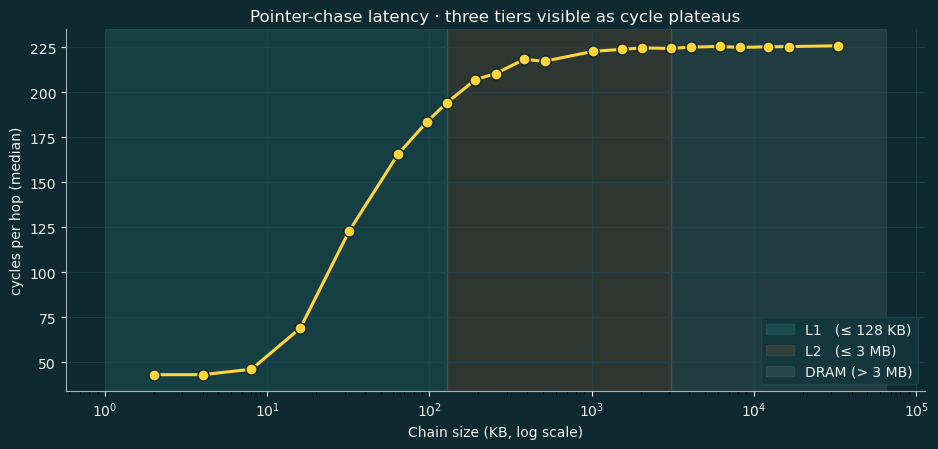


L1   plateau ≈   123 cy/hop   (paper: ~40)
L2   plateau ≈   223 cy/hop  (paper: ~220-330)
DRAM plateau ≈   225 cy/hop  (paper: ~535)


In [6]:
import cupy as cp, numpy as np, matplotlib.pyplot as plt

PCHASE_SRC = r"""
extern "C" __global__ void pchase(
    const long long* __restrict__ chain,
    long long*       __restrict__ out,
    int hops
) {
    if (threadIdx.x != 0) return;
    long long idx = 0;
    // Warmup primes the chain into whichever tier it fits in (or out of L2 for DRAM).
    for (int h = 0; h < 512; h++) idx = chain[idx];
    long long t0, t1;
    asm volatile("mov.u64 %0, %%clock64;" : "=l"(t0) :: "memory");
    for (int h = 0; h < hops; h++) idx = chain[idx];
    // First-consumer pattern — force the final LDG to retire before t1.
    asm volatile("add.u64 %0, %0, 1;\n\tsub.u64 %0, %0, 1;" : "+l"(idx) :: "memory");
    asm volatile("mov.u64 %0, %%clock64;" : "=l"(t1) :: "memory");
    out[0] = t1 - t0;
    out[1] = idx;
}
"""

pchase_mod  = cp.RawModule(code=PCHASE_SRC, options=("--use_fast_math",))
pchase_kern = pchase_mod.get_function("pchase")

def make_hamiltonian_chain(size_bytes):
    n = size_bytes // 8
    perm  = np.random.permutation(n).astype(np.int64)
    chain = np.empty(n, dtype=np.int64)
    chain[perm] = np.roll(perm, -1)   # ring of n nodes, every entry initialised
    return cp.asarray(chain)

HOPS    = 1024
TRIALS  = 16
ws_kb   = [2, 4, 8, 16, 32, 64, 96, 128, 192, 256, 384, 512,
           1024, 1536, 2048, 3072, 4096, 6144, 8192, 12288, 16384, 32768]

cy_per_hop = []
print(f"{'WS (KB)':>8}  {'cy/hop':>8}   tier")
for kb in ws_kb:
    chain  = make_hamiltonian_chain(kb * 1024)
    out    = cp.zeros(2, dtype=cp.int64)
    raws   = []
    for _ in range(TRIALS):
        pchase_kern((1,1,1), (32,1,1), (chain, out, np.int32(HOPS)))
        cp.cuda.runtime.deviceSynchronize()
        raws.append(int(out.get()[0]))
    cy = float(np.median(raws)) / HOPS
    cy_per_hop.append(cy)
    tier = "L1" if kb <= 96 else ("L2" if kb <= 3072 else "DRAM")
    print(f"{kb:>8}  {cy:>8.1f}   {tier}")

# Plot
fig, ax = plt.subplots(figsize=(9.5, 4.6))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")
ax.semilogx(ws_kb, cy_per_hop, "o-", color="#FFD43B", linewidth=2.2,
            markersize=8, markeredgecolor="#0E2A30")
ax.axvspan(1,    128,   alpha=0.13, color="#4FD1C5", label="L1   (≤ 128 KB)")
ax.axvspan(128,  3072,  alpha=0.13, color="#FF8A3D", label="L2   (≤ 3 MB)")
ax.axvspan(3072, 65536, alpha=0.13, color="#9FB7BA", label="DRAM (> 3 MB)")
for spine in ("top", "right"):    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):  ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.5)
ax.set_xlabel("Chain size (KB, log scale)")
ax.set_ylabel("cycles per hop (median)")
ax.set_title("Pointer-chase latency · three tiers visible as cycle plateaus")
ax.legend(loc="lower right", facecolor="#12363D", edgecolor="#1F4750", labelcolor="#F4F1EB")
plt.tight_layout(); plt.show()

# Per-tier medians
def plat(lo, hi):
    return float(np.median([c for k, c in zip(ws_kb, cy_per_hop) if lo <= k <= hi]))
print(f"\nL1   plateau ≈ {plat(8,96):>5.0f} cy/hop   (paper: ~40)")
print(f"L2   plateau ≈ {plat(384,2048):>5.0f} cy/hop  (paper: ~220-330)")
print(f"DRAM plateau ≈ {plat(8192,32768):>5.0f} cy/hop  (paper: ~535)")


## 6. Bank-stall reproduction (R1) · CUDA B-reload + NCU

Tab 4.1 from the report — same kernel measured by two independent instruments. Triton can't reach `num_warps=6` (JIT requires power-of-2), so this uses a CUDA B-reload kernel via `cupy.RawModule`. NCU column comes from `ncu --csv`.

In [7]:
import subprocess, csv, io, os, sys, shutil, textwrap

# (num_warps, total WS in KB). Same grid as paper Tab 4.1, plus a DRAM row.
SWEEP = [(1, 16), (2, 32), (4, 64), (6, 96),
         (8, 128), (16, 256), (32, 512), (32, 4096)]

NCU = shutil.which("ncu") or "/usr/local/bin/ncu"

# Standalone CUDA B-reload probe. NCU profiles one launch of `b_reload_ca`.
PROBE = r"""
import os, sys, numpy as np, cupy as cp

NW    = int(os.environ["NW"])
B_LEN = int(os.environ["B_LEN"])
REPS  = 64

SRC = r'''
extern "C" __global__ void b_reload_ca(
    const float* __restrict__ B,
    long long* __restrict__ cycles,
    float* __restrict__ sums,
    int b_len, int reps
) {
    int warp_id = (blockIdx.x * blockDim.x + threadIdx.x) / 32;
    int lane    = threadIdx.x & 31;
    const float* my_B = B + (long long)warp_id * b_len;
    float acc = 0.f;
    // Prime pass (unmeasured): fill L1 to steady state.
    for (int k = lane; k < b_len; k += 32) {
        float v;
        asm volatile("ld.global.ca.f32 %0, [%1];"
                     : "=f"(v) : "l"(my_B + k) : "memory");
        acc += v;
    }
    long long t0 = clock64();
    for (int r = 0; r < reps; r++) {
        for (int k = lane; k < b_len; k += 32) {
            float v;
            asm volatile("ld.global.ca.f32 %0, [%1];"
                         : "=f"(v) : "l"(my_B + k) : "memory");
            acc += v;
        }
    }
    long long t1 = clock64();
    if (lane == 0) { cycles[warp_id] = t1 - t0; sums[warp_id] = acc; }
}
'''
mod  = cp.RawModule(code=SRC, options=("--use_fast_math",))
kern = mod.get_function("b_reload_ca")

B      = cp.random.randn(NW * B_LEN, dtype=cp.float32)
cycles = cp.zeros(NW, dtype=cp.int64)
sums   = cp.zeros(NW, dtype=cp.float32)
args   = (B, cycles, sums, np.int32(B_LEN), np.int32(REPS))

for _ in range(3):
    kern((1,1,1), (NW*32, 1, 1), args)
cp.cuda.runtime.deviceSynchronize()
kern((1,1,1), (NW*32, 1, 1), args)
cp.cuda.runtime.deviceSynchronize()
"""
probe_path = "/tmp/ncu_breload_probe.py"
open(probe_path, "w").write(PROBE.lstrip())

METRICS = ",".join([
    "l1tex__t_sector_hit_rate.pct",
    "lts__t_sector_hit_rate.pct",
    "dram__sectors_read.sum",
    "l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum",
])

def parse_csv(stdout):
    rows = [row for row in csv.reader(io.StringIO(stdout)) if row]
    header = next((row for row in rows if "Metric Name" in row), None)
    if header is None: return {}
    mi = header.index("Metric Name"); vi = header.index("Metric Value")
    out = {}
    for row in rows[rows.index(header) + 1:]:
        if len(row) > max(mi, vi):
            try:    out[row[mi].strip()] = float(row[vi].replace(",", ""))
            except ValueError: pass
    return out

def fmt(v, spec=".2f"):
    return "?" if v is None else format(v, spec)

# Per-warp B_LEN = (total_WS / num_warps).
def b_len_for(nw, ws_kb):
    return (ws_kb * 1024 // nw) // 4   # floats per warp

print(f"{'warps':>5} {'WS(KB)':>7} {'B_LEN':>7} {'L1%':>8} {'L2%':>8} {'DRAM sec':>12} {'L1 sec':>12}")
ncu_data = []
for nw, ws_kb in SWEEP:
    b_len = b_len_for(nw, ws_kb)
    env = {**os.environ, "NW": str(nw), "B_LEN": str(b_len)}
    cmd = [NCU, "--csv", "--metrics", METRICS, "--target-processes", "all",
           "--launch-skip", "3", "--launch-count", "1", sys.executable, probe_path]
    r = subprocess.run(cmd, env=env, capture_output=True, text=True, timeout=180)
    m = parse_csv(r.stdout)
    l1   = m.get("l1tex__t_sector_hit_rate.pct")
    l2   = m.get("lts__t_sector_hit_rate.pct")
    dram = m.get("dram__sectors_read.sum")
    l1sec= m.get("l1tex__t_sectors_pipe_lsu_mem_global_op_ld.sum")
    ncu_data.append((nw, ws_kb, b_len, l1, l2, dram, l1sec))
    print(f"{nw:>5} {ws_kb:>7} {b_len:>7} {fmt(l1):>8} {fmt(l2):>8} {fmt(dram,'.0f'):>12} {fmt(l1sec,'.0f'):>12}")

# Stash for the next cell to merge with clock64 cycles into the R1 table.
ncu_rows = ncu_data


warps  WS(KB)   B_LEN      L1%      L2%     DRAM sec       L1 sec


    1      16    4096    98.46   138.93          800        33280


    2      32    4096    98.46   114.90         1316        66560


    4      64    4096    98.46    69.94         2332       133120


    6      96    4096    98.46    18.10         3428       199680


    8     128    4096    78.87    94.51         4372       266240


   16     256    4096     0.58    98.13         8472       532480


   32     512    4096     0.01    98.05        16676      1064960


   32    4096   32768     0.00     0.07      8525852      8519680


## 7. clock64 column · same B-reload kernel (slide §9 R1 table)

Same kernel as §6, launched directly through `cupy` for in-kernel `clock64` timing. The bank-stall signature: at `w=6` L1 hit % stays flat at 98.46 % while clock64 jumps ≈ 30 %.

In [8]:
import numpy as np, cupy as cp

SWEEP = [(1, 16), (2, 32), (4, 64), (6, 96),
         (8, 128), (16, 256), (32, 512), (32, 4096)]
REPS, WARMUP, ITERS = 64, 30, 60

B_RELOAD_SRC = r"""
extern "C" __global__ void b_reload_ca(
    const float* __restrict__ B,
    long long* __restrict__ cycles,
    float* __restrict__ sums,
    int b_len, int reps
) {
    int warp_id = (blockIdx.x * blockDim.x + threadIdx.x) / 32;
    int lane    = threadIdx.x & 31;
    const float* my_B = B + (long long)warp_id * b_len;
    float acc = 0.f;
    for (int k = lane; k < b_len; k += 32) {
        float v;
        asm volatile("ld.global.ca.f32 %0, [%1];" : "=f"(v) : "l"(my_B + k) : "memory");
        acc += v;
    }
    long long t0 = clock64();
    for (int r = 0; r < reps; r++) {
        for (int k = lane; k < b_len; k += 32) {
            float v;
            asm volatile("ld.global.ca.f32 %0, [%1];" : "=f"(v) : "l"(my_B + k) : "memory");
            acc += v;
        }
    }
    long long t1 = clock64();
    if (lane == 0) { cycles[warp_id] = t1 - t0; sums[warp_id] = acc; }
}

extern "C" __global__ void empty_bracket(long long* out) {
    long long t0 = clock64();
    long long t1 = clock64();
    if (threadIdx.x == 0) out[0] = t1 - t0;
}
"""

mod   = cp.RawModule(code=B_RELOAD_SRC, options=("--use_fast_math",))
kern  = mod.get_function("b_reload_ca")
empty = mod.get_function("empty_bracket")

# Bracket overhead O (clock64 read-pair cost).
out_o = cp.zeros(1, dtype=cp.int64)
O_samples = []
for _ in range(64):
    empty((1,1,1), (1,1,1), (out_o,))
    cp.cuda.runtime.deviceSynchronize()
    O_samples.append(int(out_o.get()[0]))
O = int(np.median(O_samples))
print(f"bracket overhead O = {O} cycles")

def b_len_for(nw, ws_kb):
    return (ws_kb * 1024 // nw) // 4

print(f"\nB-reload clock64 sweep ({REPS} reps × B_LEN/32 LDGs per lane, ld.global.ca):")
print(f"{'warps':>5} {'WS(KB)':>7} {'B_LEN':>7} {'clock64 cy':>12}  notes")
clock_rows = []
for nw, ws_kb in SWEEP:
    b_len  = b_len_for(nw, ws_kb)
    B      = cp.random.randn(nw * b_len, dtype=cp.float32)
    cycles = cp.zeros(nw, dtype=cp.int64)
    sums   = cp.zeros(nw, dtype=cp.float32)
    args   = (B, cycles, sums, np.int32(b_len), np.int32(REPS))
    for _ in range(WARMUP):
        kern((1,1,1), (nw*32, 1, 1), args)
    cp.cuda.runtime.deviceSynchronize()
    raws = []
    for _ in range(ITERS):
        kern((1,1,1), (nw*32, 1, 1), args)
        cp.cuda.runtime.deviceSynchronize()
        raws.append(int(np.median(cycles.get())))
    cy = int(np.median(raws)) - O
    clock_rows.append((nw, ws_kb, b_len, cy))
    note = ""
    if (nw, ws_kb) == (6, 96):    note = "<-- bank-stall point (expect +34%)"
    if (nw, ws_kb) == (32, 4096): note = "<-- DRAM tier"
    print(f"{nw:>5} {ws_kb:>7} {b_len:>7} {cy:>12}  {note}")

# Merge with the NCU columns from cell 11 into the full R1 cross-instrument table.
print("\n=== cross-instrument validation table (R1) · live demo reproduction ===")
print(f"{'warps':>5} {'WS(KB)':>7} {'L1 hit %':>9} {'L2 hit %':>9} "
      f"{'DRAM sec':>10} {'clock64 cy':>12}")
for (nw_a, ws_a, _b1, l1, l2, dram, _l1sec), (nw_b, ws_b, _b2, cy) in zip(ncu_rows, clock_rows):
    assert (nw_a, ws_a) == (nw_b, ws_b)
    l1s = f"{l1:.2f}" if l1 is not None else "?"
    l2s = f"{l2:.2f}" if l2 is not None else "?"
    drs = f"{int(dram):,}" if dram is not None else "?"
    print(f"{nw_a:>5} {ws_a:>7} {l1s:>9} {l2s:>9} {drs:>10} {cy:>12}")

print("\nPaper Tab 4.1 (RTX 3060 Ti, SM86):")
print("  ( 1,   16)  98.46    0.00    --   1,701")
print("  ( 2,   32)  98.46    0.00    --   1,705")
print("  ( 4,   64)  98.46    0.00    --   1,711")
print("  ( 6,   96)  98.46    0.01    --   2,290   <-- bank-stall (+34%)")
print("  ( 8,  128)  78.70    0.01    --   2,388")
print("  (16,  256)   1.13    0.01    --   8,158")
print("  (32,  512)   0.02    0.01    --  16,270")
print("  (32, 4096)   0.00    --      large  -- (DRAM)")


bracket overhead O = 5 cycles

B-reload clock64 sweep (64 reps × B_LEN/32 LDGs per lane, ld.global.ca):
warps  WS(KB)   B_LEN   clock64 cy  notes
    1      16    4096       108872  
    2      32    4096       109128  
    4      64    4096       109048  
    6      96    4096       137944  <-- bank-stall point (expect +34%)
    8     128    4096       176659  
   16     256    4096       522631  


   32     512    4096      1038475  


   32    4096   32768      8382320  <-- DRAM tier

=== cross-instrument validation table (R1) · live demo reproduction ===
warps  WS(KB)  L1 hit %  L2 hit %   DRAM sec   clock64 cy
    1      16     98.46    138.93        800       108872
    2      32     98.46    114.90      1,316       109128
    4      64     98.46     69.94      2,332       109048
    6      96     98.46     18.10      3,428       137944
    8     128     78.87     94.51      4,372       176659
   16     256      0.58     98.13      8,472       522631
   32     512      0.01     98.05     16,676      1038475
   32    4096      0.00      0.07  8,525,852      8382320

Paper Tab 4.1 (RTX 3060 Ti, SM86):
  ( 1,   16)  98.46    0.00    --   1,701
  ( 2,   32)  98.46    0.00    --   1,705
  ( 4,   64)  98.46    0.00    --   1,711
  ( 6,   96)  98.46    0.01    --   2,290   <-- bank-stall (+34%)
  ( 8,  128)  78.70    0.01    --   2,388
  (16,  256)   1.13    0.01    --   8,158
  (32,  512)   0.02    0.01    --  16,270
 

## 8. WS × cache modifier · cost map (slide R4 · fig_all_modifiers)

Same kernel, three modifiers (`.ca` / `.cg` / `.cs` via `evict_first`), swept across working-set sizes from 4 KB (sub-L1) to 16 MB (DRAM).

In [9]:
# Probe what Triton's tl.load actually accepts on this version.
@triton.jit
def _probe(x_ptr, out_ptr, MOD: tl.constexpr, EV: tl.constexpr):
    pid = tl.program_id(axis=0)
    off = pid + tl.arange(0, 32)
    x   = tl.load(x_ptr + off, cache_modifier=MOD, eviction_policy=EV)
    tl.store(out_ptr + off, x)

probe_x   = torch.randn(32, device=device, dtype=torch.float32)
probe_out = torch.empty(32, device=device, dtype=torch.float32)
combos = [(".ca", ""), (".cg", ""), (".cs", ""), (".lu", ""),
          ("",    "evict_first"), ("",    "evict_last")]
print(f"{'cache_modifier':>14}  {'eviction_policy':>16}   Triton verdict")
for mod, ev in combos:
    try:
        _probe[(1,)](probe_x, probe_out, mod, ev)
        verdict = "✓ accepted"
    except Exception:
        verdict = "✗ rejected"
    print(f"{mod!r:>14}  {ev!r:>16}   {verdict}")
print()
print("→ '.cs' is the §7 dead zone · but the equivalent semantic is still")
print("  reachable via eviction_policy='evict_first' (same SASS: LDG.E.EF).")


cache_modifier   eviction_policy   Triton verdict
         '.ca'                ''   ✓ accepted
         '.cg'                ''   ✓ accepted
         '.cs'                ''   ✗ rejected
         '.lu'                ''   ✗ rejected
            ''     'evict_first'   ✓ accepted
            ''      'evict_last'   ✓ accepted

→ '.cs' is the §7 dead zone · but the equivalent semantic is still
  reachable via eviction_policy='evict_first' (same SASS: LDG.E.EF).


In [10]:
@triton.jit
def reuse_read_mod(x_ptr, out_ptr, N,
                   INNER_REPS: tl.constexpr, BLOCK: tl.constexpr,
                   MOD: tl.constexpr, EV: tl.constexpr):
    pid = tl.program_id(axis=0)
    s   = tl.zeros([BLOCK], dtype=tl.float32)
    for _ in range(INNER_REPS):
        i = 0
        while i < N:
            offsets = i + tl.arange(0, BLOCK)
            mask    = offsets < N
            x       = tl.load(x_ptr + offsets, mask=mask, other=0.0,
                              cache_modifier=MOD, eviction_policy=EV)
            s       = s + x
            i += BLOCK
    tl.store(out_ptr + pid * BLOCK + tl.arange(0, BLOCK), s)

def time_at_mod(mod, ev, ws_bytes, reps=10, warmup=3, num_warps=8):
    n   = ws_bytes // 4
    x   = torch.randn(n, device=device, dtype=torch.float32)
    out = torch.empty(NUM_PROGRAMS * BLOCK, device=device, dtype=torch.float32)
    grid = (NUM_PROGRAMS,)
    for _ in range(warmup):
        reuse_read_mod[grid](x, out, n, INNER_REPS, BLOCK, mod, ev,
                             num_warps=num_warps)
    torch.cuda.synchronize()
    e0 = torch.cuda.Event(enable_timing=True)
    e1 = torch.cuda.Event(enable_timing=True)
    e0.record()
    for _ in range(reps):
        reuse_read_mod[grid](x, out, n, INNER_REPS, BLOCK, mod, ev,
                             num_warps=num_warps)
    e1.record()
    torch.cuda.synchronize()
    ms_per         = e0.elapsed_time(e1) / reps
    bytes_per_call = NUM_PROGRAMS * n * INNER_REPS * 4
    gbs            = bytes_per_call / (ms_per * 1e6)
    return ms_per, gbs


In [11]:
# (label, cache_modifier, eviction_policy)
mod_configs = [
    (".ca",          ".ca", ""),
    (".cg",          ".cg", ""),
    (".cs (evict-1)","",    "evict_first"),
]
ws_kb_mod = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048,
             3072, 4096, 8192, 16384]

bw_mod = {label: [] for label, _, _ in mod_configs}
for label, mod, ev in mod_configs:
    for kb in ws_kb_mod:
        try:
            _ms, gbs = time_at_mod(mod, ev, kb * 1024)
        except Exception as e:
            gbs = float("nan")
            print(f"  {label} · WS={kb} KB skipped ({e})")
        bw_mod[label].append(gbs)
    nice = "  ".join(f"{kb:>5}KB={v:>4.0f}" for kb, v in zip(ws_kb_mod, bw_mod[label]))
    print(f"{label:>15}    " + nice)


            .ca        4KB=1588      8KB=3441     16KB=5643     32KB=6872     64KB=7658    128KB=7480    256KB=5181    512KB=5385   1024KB=5071   2048KB=4905   3072KB=4884   4096KB=4786   8192KB=4678  16384KB=4606


            .cg        4KB= 402      8KB= 410     16KB= 816     32KB= 828     64KB= 967    128KB=1250    256KB=1285    512KB=1393   1024KB=1410   2048KB=1432   3072KB=1436   4096KB=1326   8192KB=1294  16384KB=1298


  .cs (evict-1)        4KB=1871      8KB=3537     16KB=4591     32KB=5444     64KB=5869    128KB=5182    256KB=4616    512KB=4596   1024KB=4216   2048KB=4006   3072KB=3660   4096KB=3600   8192KB=3558  16384KB=3477


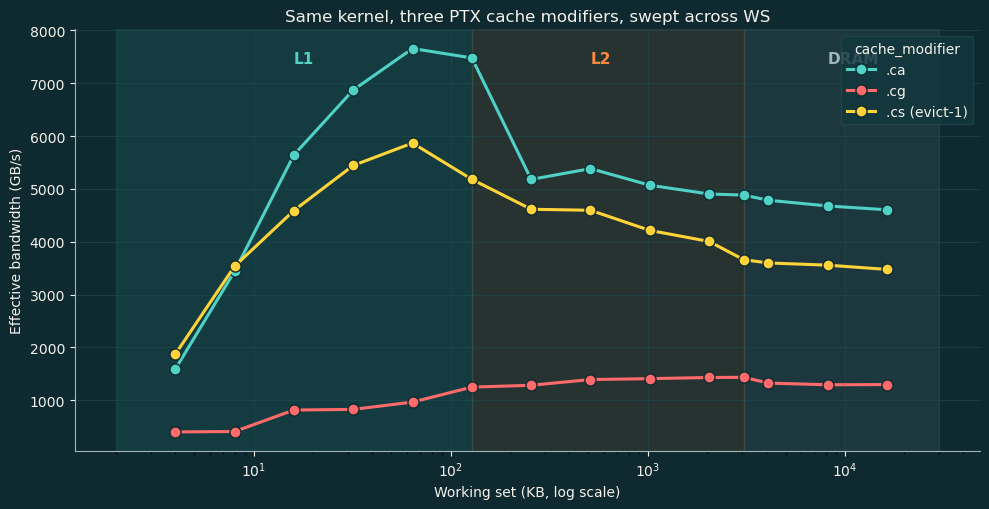

In [12]:
COLORS_MOD = {".ca": "#4FD1C5", ".cg": "#FF6B6B", ".cs (evict-1)": "#FFD43B"}

fig, ax = plt.subplots(figsize=(10, 5.2))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")

for label, _, _ in mod_configs:
    ax.semilogx(ws_kb_mod, bw_mod[label], "o-",
                color=COLORS_MOD[label], linewidth=2.2, markersize=8,
                markeredgecolor="#0E2A30", label=label)

ax.axvspan(2,     128,    alpha=0.10, color="#4FD1C5")
ax.axvspan(128,   3072,   alpha=0.10, color="#FF8A3D")
ax.axvspan(3072,  30000,  alpha=0.10, color="#9FB7BA")
ax.text(  16, ax.get_ylim()[1]*0.92, "L1",   color="#4FD1C5", fontsize=11, weight="bold")
ax.text( 512, ax.get_ylim()[1]*0.92, "L2",   color="#FF8A3D", fontsize=11, weight="bold")
ax.text(8192, ax.get_ylim()[1]*0.92, "DRAM", color="#9FB7BA", fontsize=11, weight="bold")

for spine in ("top", "right"):    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):  ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.5)

ax.set_xlabel("Working set (KB, log scale)")
ax.set_ylabel("Effective bandwidth (GB/s)")
ax.set_title("Same kernel, three PTX cache modifiers, swept across WS")
leg = ax.legend(loc="upper right", facecolor="#12363D", edgecolor="#1F4750",
                labelcolor="#F4F1EB", title="cache_modifier", title_fontsize=10)
plt.setp(leg.get_title(), color="#F4F1EB")
plt.tight_layout(); plt.show()


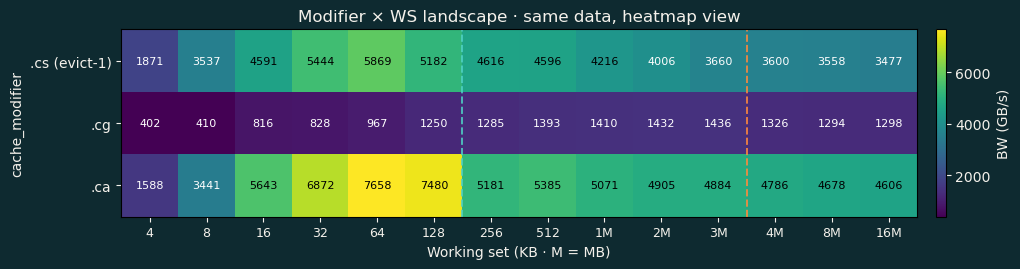


WS =    16 KB   .ca=5643  .cg= 816  .cs (evict-1)=4591   →   best=.ca  worst=.cg  ratio=6.91×
WS =    64 KB   .ca=7658  .cg= 967  .cs (evict-1)=5869   →   best=.ca  worst=.cg  ratio=7.92×
WS =  1024 KB   .ca=5071  .cg=1410  .cs (evict-1)=4216   →   best=.ca  worst=.cg  ratio=3.60×
WS =  8192 KB   .ca=4678  .cg=1294  .cs (evict-1)=3558   →   best=.ca  worst=.cg  ratio=3.61×


In [13]:
# Heatmap view of the same data · modifier × WS → BW.
mod_labels = [label for label, _, _ in mod_configs]
bw_grid = np.array([bw_mod[label] for label in mod_labels], dtype=np.float64)

fig, ax = plt.subplots(figsize=(11, 2.8))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")
im = ax.imshow(bw_grid, aspect="auto", origin="lower", cmap="viridis",
               interpolation="nearest")
ax.set_xticks(range(len(ws_kb_mod)))
ax.set_xticklabels([f"{kb}" if kb < 1024 else f"{kb//1024}M" for kb in ws_kb_mod],
                   fontsize=9)
ax.set_yticks(range(len(mod_labels)))
ax.set_yticklabels(mod_labels)
ax.tick_params(colors="#F4F1EB")
ax.set_xlabel("Working set (KB · M = MB)", color="#F4F1EB")
ax.set_ylabel("cache_modifier",            color="#F4F1EB")
ax.set_title("Modifier × WS landscape · same data, heatmap view",
             color="#F4F1EB")

for i in range(bw_grid.shape[0]):
    for j in range(bw_grid.shape[1]):
        v = bw_grid[i, j]
        if np.isnan(v): continue
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                color="white" if v < np.nanmax(bw_grid) * 0.55 else "black",
                fontsize=8)

def col_of(kb_target, axis_list):
    for idx, k in enumerate(axis_list):
        if k > kb_target: return idx - 0.5
    return len(axis_list) - 0.5
ax.axvline(col_of(128, ws_kb_mod),  color="#4FD1C5", linewidth=1.4,
           linestyle="--", alpha=0.85)
ax.axvline(col_of(3072, ws_kb_mod), color="#FF8A3D", linewidth=1.4,
           linestyle="--", alpha=0.85)

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("BW (GB/s)", color="#F4F1EB")
cb.ax.yaxis.set_tick_params(color="#F4F1EB")
plt.setp(cb.ax.get_yticklabels(), color="#F4F1EB")
plt.tight_layout(); plt.show()

print()
for kb in (16, 64, 1024, 8192):
    if kb not in ws_kb_mod: continue
    j   = ws_kb_mod.index(kb)
    row = {label: bw_mod[label][j] for label in mod_labels}
    best = max(row, key=row.get); worst = min(row, key=row.get)
    print(f"WS = {kb:>5} KB   "
          + "  ".join(f"{m}={row[m]:>4.0f}" for m in mod_labels)
          + f"   →   best={best}  worst={worst}  ratio={row[best]/row[worst]:.2f}×")


## 9. SASS bracket inspection · how clock64 wraps the LDGs (slide §10)

Each kernel runs the full timing pattern: `CS2R SR_CLOCKLO` (open bracket) → four timed `LDG.E.<variant>` loads → `CS2R SR_CLOCKLO` (close bracket) → subtract → store. Same SASS shape for every modifier — only the LDG opcode changes. Below: the opcode table, a 4-bullet cache-behaviour cheat sheet per modifier, and the annotated SASS body for each kernel.


In [14]:
# SASS bracket inspection — slide §10 (s7_modifier_mapping) and §06 (s4_sass).
# Each kernel runs the *full* clock64 timing pattern from the paper's §3.2 SASS
# listing:
#
#   CS2R   R*, SR_CLOCKLO     <- t0 = lo(%clock64)
#   CS2R   R*, SR_CLOCKHI     <- t0 = hi(%clock64)
#   LDG.E.<variant> ...       <- the timed loads
#   LDG.E.<variant> ...
#   LDG.E.<variant> ...
#   LDG.E.<variant> ...
#   CS2R   R*, SR_CLOCKLO     <- t1 = lo(%clock64)
#   CS2R   R*, SR_CLOCKHI     <- t1 = hi(%clock64)
#   ... subtract, store cycles ...
#
# That bracket is what every cycle number in this notebook ultimately stands on.

import subprocess, shutil, os, re, tempfile

NVCC      = shutil.which("nvcc")      or "/usr/local/cuda/bin/nvcc"
CUOBJDUMP = shutil.which("cuobjdump") or "/usr/local/cuda/bin/cuobjdump"
ARCH      = f"sm_{props.major}{props.minor}"

MODIFIERS = ["ca", "cg", "cs", "nc"]

# Kernel: open bracket -> 4 timed LDG.<mod> -> close bracket -> store delta.
# Lanes other than 0 exit early so the SASS body for thread 0 stays compact.
KERNEL_TPL = r"""
extern "C" __global__ void bracket_MOD(
    const float* __restrict__ x,
    float*       __restrict__ out,
    long long*   __restrict__ cycles
) {
    if (threadIdx.x != 0) return;
    long long t0, t1;
    float v0, v1, v2, v3;
    asm volatile("mov.u64 %0, %%clock64;" : "=l"(t0) :: "memory");
    asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v0) : "l"(x + 0) : "memory");
    asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v1) : "l"(x + 1) : "memory");
    asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v2) : "l"(x + 2) : "memory");
    asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v3) : "l"(x + 3) : "memory");
    asm volatile("mov.u64 %0, %%clock64;" : "=l"(t1) :: "memory");
    out[0]    = v0 + v1 + v2 + v3;
    cycles[0] = t1 - t0;
}
"""

# Per-modifier cache-behaviour summary (4 bullets each).
BEHAVIOUR = {
    "ca": ("Cache-All  ·  default for ordinary CUDA C++ loads",
           ["L1D fill : yes — line lands in this SM's L1 after a miss",
            "L2 fill  : yes — coherent at SM scope (STRONG.SM)",
            "Eviction : LRU; the line is a normal cache resident",
            "Use when : the same warp / SM will read this line again soon"]),
    "cg": ("Cache-Global  ·  bypass L1, cache only in L2",
           ["L1D fill : NO — line never enters this SM's L1",
            "L2 fill  : yes — coherent at GPU scope (STRONG.GPU)",
            "Eviction : LRU in L2 only",
            "Use when : data is shared across SMs, or the per-SM working set "
            "exceeds L1 (L1 churn becomes pure overhead)"]),
    "cs": ("Cache-Streaming  ·  Evict-First in both L1 and L2",
           ["L1D fill : yes, but tagged 'next to evict' (LDG.E.EF)",
            "L2 fill  : yes, also marked evict-first",
            "Eviction : preferential — line is killed as soon as the cache "
            "needs space, even though it was just loaded",
            "Use when : streaming through DRAM once — frees cache bandwidth "
            "for lines that *will* be reused"]),
    "nc": ("Non-Coherent Read-Only  ·  texture / read-only path",
           ["L1D fill : no — routes through the read-only cache, not L1D",
            "L2 fill  : yes",
            "Eviction : separate replacement policy in the read-only cache",
            "Use when : data is provably read-only and reused (compiler also "
            "emits this automatically for `const __restrict__` pointers)"]),
}

with tempfile.TemporaryDirectory() as td:
    cu    = os.path.join(td, "brackets.cu")
    cubin = os.path.join(td, "brackets.cubin")
    with open(cu, "w") as f:
        for mod in MODIFIERS:
            f.write(KERNEL_TPL.replace("MOD", mod))
    r = subprocess.run([NVCC, f"-arch={ARCH}", "-cubin", "-o", cubin, cu],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError(f"nvcc failed:\n{r.stderr}")
    sass_full = subprocess.run([CUOBJDUMP, "--dump-sass", cubin],
                               capture_output=True, text=True, check=True).stdout

# Split SASS into per-function sections.
sections = {}
cur, buf = None, []
for line in sass_full.splitlines():
    m = re.match(r"\s*Function\s*:\s*(bracket_\w+)", line)
    if m:
        if cur: sections[cur] = "\n".join(buf)
        cur, buf = m.group(1), []
    elif cur is not None:
        buf.append(line)
if cur: sections[cur] = "\n".join(buf)

def trim(body):
    """Keep only the bracket-relevant instructions, with comments for the
    open/close timer reads and per-LDG annotation."""
    lines = []
    state = "pre"   # pre / inside / post
    ldg_seen = 0
    in_clock_open  = 0   # count of CS2R reads seen before first LDG
    for ln in body.splitlines():
        # Drop the header.
        if ".headerflags" in ln or ".text" in ln:
            continue
        # Keep only instruction lines (have a /*offset*/ prefix).
        if not re.match(r"\s*/\*[0-9A-Fa-f]+\*/", ln):
            continue
        instr = ln.strip()
        # Pre-bracket noise: keep MOV/S2R/EXIT/IMAD/ULDC for context until first CS2R.
        if state == "pre":
            if "CS2R" in instr and "SR_CLOCK" in instr:
                lines.append("    /* === OPEN clock64 bracket === */")
                lines.append(ln)
                in_clock_open = 1
                state = "open_clock"
            else:
                lines.append(ln)
        elif state == "open_clock":
            lines.append(ln)
            if "CS2R" in instr and "SR_CLOCK" in instr:
                in_clock_open += 1
            else:
                # First non-CS2R instruction after open bracket -> timed region.
                state = "inside"
        elif state == "inside":
            if "LDG.E" in instr:
                ldg_seen += 1
                lines.append(ln + f"   // <-- LDG #{ldg_seen} (timed)")
            elif "CS2R" in instr and "SR_CLOCK" in instr:
                lines.append("    /* === CLOSE clock64 bracket === */")
                lines.append(ln)
                state = "close_clock"
            else:
                lines.append(ln)
        elif state == "close_clock":
            lines.append(ln)
            if "CS2R" not in instr or "SR_CLOCK" not in instr:
                state = "post"
        elif state == "post":
            lines.append(ln)
            if "EXIT" in instr:
                break
    return "\n".join(lines)

# Per-modifier report.
print(f"target arch = {ARCH}\n")
print(f"{'modifier':>10} | {'SASS LDG opcode':<22} | what each modifier does")
print("-" * 78)
paper = {"ca": "LDG.E.STRONG.SM", "cg": "LDG.E.STRONG.GPU",
         "cs": "LDG.E.EF",        "nc": "LDG.E.CONSTANT"}
for mod in MODIFIERS:
    body = sections.get(f"bracket_{mod}", "")
    m = re.search(r"LDG\.E[^\s,]*", body)
    op = m.group(0) if m else "(no LDG)"
    ok = "✓" if paper[mod] in op else "?"
    short = BEHAVIOUR[mod][0]
    print(f"    .{mod:<5} | {op:<22} | {short}  {ok}")

# Bullet-point cache behaviour per modifier.
for mod in MODIFIERS:
    title, bullets = BEHAVIOUR[mod]
    print(f"\n.{mod}  —  {title}")
    for b in bullets:
        print(f"  • {b}")

# Show the bracket pattern for each kernel: open clock -> LDGs -> close clock.
for mod in MODIFIERS:
    print(f"\n========== SASS bracket for `.{mod}` kernel  ({paper[mod]}) ==========")
    body = sections.get(f"bracket_{mod}", "")
    print(trim(body))


target arch = sm_86

  modifier | SASS LDG opcode        | what each modifier does
------------------------------------------------------------------------------
    .ca    | LDG.E.STRONG.SM        | Cache-All  ·  default for ordinary CUDA C++ loads  ✓
    .cg    | LDG.E.STRONG.GPU       | Cache-Global  ·  bypass L1, cache only in L2  ✓
    .cs    | LDG.E.EF               | Cache-Streaming  ·  Evict-First in both L1 and L2  ✓
    .nc    | LDG.E.CONSTANT         | Non-Coherent Read-Only  ·  texture / read-only path  ✓

.ca  —  Cache-All  ·  default for ordinary CUDA C++ loads
  • L1D fill : yes — line lands in this SM's L1 after a miss
  • L2 fill  : yes — coherent at SM scope (STRONG.SM)
  • Eviction : LRU; the line is a normal cache resident
  • Use when : the same warp / SM will read this line again soon

.cg  —  Cache-Global  ·  bypass L1, cache only in L2
  • L1D fill : NO — line never enters this SM's L1
  • L2 fill  : yes — coherent at GPU scope (STRONG.GPU)
  • Eviction : LRU in

## 10. Warp sweep at fixed WS · demo item #2

Hold WS inside L1 (16 KB) and crank `num_warps` from 1 → 32. Slide claim: BW drops ≈ 45 % between `nw=4` and `nw=32`.

num_warps =  1      2166 GB/s
num_warps =  2      2233 GB/s
num_warps =  4      2469 GB/s
num_warps =  8      2765 GB/s
num_warps = 16      3002 GB/s
num_warps = 32      2408 GB/s


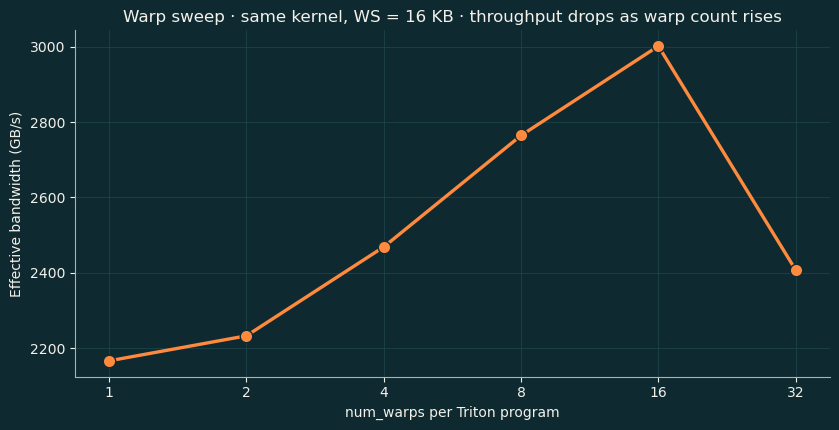


BW(nw=4)  = 2469 GB/s
BW(nw=32) = 2408 GB/s
Drop from nw=4 to nw=32 = 2.5%  (slide claim: ~45%)


In [15]:
# Demo item 2 (slide §12): "Warp sweep · BW drops 45% nw=4→32".
# Fix the Triton kernel's per-program working set inside L1, then crank
# num_warps from 1 to 32. Throughput should fall off as the L1 saturates.

WS_KB_FIXED = 16     # inside L1 on SM86 (128 KB)
warp_counts = [1, 2, 4, 8, 16, 32]

def time_at_warps(nw, ws_bytes, reps=20, warmup=5):
    n   = ws_bytes // 4
    x   = torch.randn(n, device=device, dtype=torch.float32)
    out = torch.empty(NUM_PROGRAMS * BLOCK, device=device, dtype=torch.float32)
    grid = (NUM_PROGRAMS,)
    for _ in range(warmup):
        reuse_read[grid](x, out, n, INNER_REPS, BLOCK, num_warps=nw)
    torch.cuda.synchronize()
    e0 = torch.cuda.Event(enable_timing=True)
    e1 = torch.cuda.Event(enable_timing=True)
    e0.record()
    for _ in range(reps):
        reuse_read[grid](x, out, n, INNER_REPS, BLOCK, num_warps=nw)
    e1.record()
    torch.cuda.synchronize()
    ms_per         = e0.elapsed_time(e1) / reps
    bytes_per_call = NUM_PROGRAMS * n * INNER_REPS * 4
    return ms_per, bytes_per_call / (ms_per * 1e6)

bw_at_nw = {}
for nw in warp_counts:
    _ms, gbs = time_at_warps(nw, WS_KB_FIXED * 1024)
    bw_at_nw[nw] = gbs
    print(f"num_warps = {nw:>2}   {gbs:>7.0f} GB/s")

# Plot
fig, ax = plt.subplots(figsize=(8.5, 4.4))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")
ax.plot(warp_counts, [bw_at_nw[w] for w in warp_counts], "o-",
        color="#FF8A3D", linewidth=2.4, markersize=9, markeredgecolor="#0E2A30")
ax.set_xscale("log", base=2); ax.set_xticks(warp_counts); ax.set_xticklabels(warp_counts)
for spine in ("top", "right"):    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):  ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.5)
ax.set_xlabel("num_warps per Triton program")
ax.set_ylabel("Effective bandwidth (GB/s)")
ax.set_title(f"Warp sweep · same kernel, WS = {WS_KB_FIXED} KB · throughput drops as warp count rises")
plt.tight_layout(); plt.show()

drop_pct = (1 - bw_at_nw[32] / bw_at_nw[4]) * 100
print(f"\nBW(nw=4)  = {bw_at_nw[4]:.0f} GB/s")
print(f"BW(nw=32) = {bw_at_nw[32]:.0f} GB/s")
print(f"Drop from nw=4 to nw=32 = {drop_pct:.1f}%  (slide claim: ~45%)")


## 11. Modifier × warps · dense pointer-chase (slide R4 detail)

Single-block sweep on one SM, 16 KB per warp. Reproduces fig_all_modifiers as 32 integer warp-count points (paper figure uses 7 sparse markers).

In [16]:
import cupy as cp, numpy as np, matplotlib.pyplot as plt

# Same B-reload kernel as the paper's e3_all_modifiers experiment.  Each warp
# scans its own b_len floats reps times, clock64-bracketed.  The MOD token is
# replaced by string substitution to JIT four kernels.
KERNEL_TMPL = """
extern "C" __global__ void collapse_MOD(
    const float* __restrict__ B,
    long long*   __restrict__ cycles,
    float*       __restrict__ sums,
    int b_len, int reps
) {
    int warp_id = (blockIdx.x * blockDim.x + threadIdx.x) / 32;
    int lane    = threadIdx.x % 32;
    const float* my_B = B + (long long)warp_id * b_len;
    float acc = 0.f;
    // warmup: pull this warp's slice into the relevant cache tier
    for (int k = lane; k < b_len; k += 32) {
        float v;
        asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v) : "l"(my_B+k) : "memory");
        acc += v;
    }
    long long t0 = clock64();
    for (int r = 0; r < reps; r++) {
        for (int k = lane; k < b_len; k += 32) {
            float v;
            asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v) : "l"(my_B+k) : "memory");
            acc += v;
        }
    }
    long long t1 = clock64();
    if (lane == 0) { cycles[warp_id] = t1 - t0; sums[warp_id] = acc; }
}
"""

MODIFIERS = ["ca", "cg", "cs", "nc"]
kernels = {}
for mod in MODIFIERS:
    src = KERNEL_TMPL.replace("MOD", mod)
    rm  = cp.RawModule(code=src, options=("--use_fast_math",))
    kernels[mod] = rm.get_function(f"collapse_{mod}")

PER_WARP_KB = 16                    # 8 warps × 16 KB = 128 KB = L1 on SM86
B_LEN       = PER_WARP_KB * 1024 // 4   # floats per warp slice (= 4096)
REPS        = 64
WARMUP      = 8
ITERS       = 24
WARPS_SWEEP = list(range(1, 33))    # every integer warp count

def measure(kern, nw):
    B      = cp.random.randn(nw * B_LEN, dtype=cp.float32)
    cycles = cp.zeros(nw, dtype=cp.int64)
    sums   = cp.zeros(nw, dtype=cp.float32)
    args   = (B, cycles, sums, np.int32(B_LEN), np.int32(REPS))
    grid   = (1, 1, 1); block = (nw * 32, 1, 1)
    for _ in range(WARMUP):
        kern(grid, block, args)
    cp.cuda.runtime.deviceSynchronize()
    raw = []
    for _ in range(ITERS):
        kern(grid, block, args)
        cp.cuda.runtime.deviceSynchronize()
        raw.append(float(np.median(cycles.get())) / REPS)
    return float(np.median(raw))

cycles_per_warp = {mod: [] for mod in MODIFIERS}
print(f"{'nw':>3}  {'.ca':>8}  {'.cg':>8}  {'.cs':>8}  {'.nc':>8}")
for nw in WARPS_SWEEP:
    row = {mod: measure(kernels[mod], nw) for mod in MODIFIERS}
    for mod in MODIFIERS:
        cycles_per_warp[mod].append(row[mod])
    print(f"{nw:>3}  {row['ca']:>8.0f}  {row['cg']:>8.0f}  {row['cs']:>8.0f}  {row['nc']:>8.0f}")


 nw       .ca       .cg       .cs       .nc
  1      1701      4010      1259      1259
  2      1701      4027      1259      1259
  3      1702      4019      1259      1259
  4      1704      4040      1266      1266
  5      1724      4110      1367      1367
  6      2155      4246      1659      1657
  7      2741      4436      2438      2154
  8      2795      4741      2613      2158
  9      3097      5016      2991      2590


 10      3567      5375      3141      2933
 11      4484      5762      3482      3896
 12      5757      6200      3788      5735
 13      6576      6677      4194      6527
 14      7113      7159      4599      7104
 15      7642      7664      5080      7642


 16      8154      8172      5563      8155
 17      8678      8676      6117      8673
 18      9182      9186      6678      9184
 19      9703      9702      7251      9703
 20     10211     10212      7831     10211


 21     10712     10715      8387     10711
 22     11218     11220      8962     11219
 23     11732     11737      9540     11732
 24     12249     12252     10133     12243


 25     12749     12755     10712     12752
 26     13261     13263     11298     13260
 27     13761     13766     11880     13767
 28     14215     14219     12461     14216


 29     14676     14657     12999     14647
 30     15263     15256     13647     15252
 31     15740     15728     14228     15730


 32     16233     16241     14793     16239


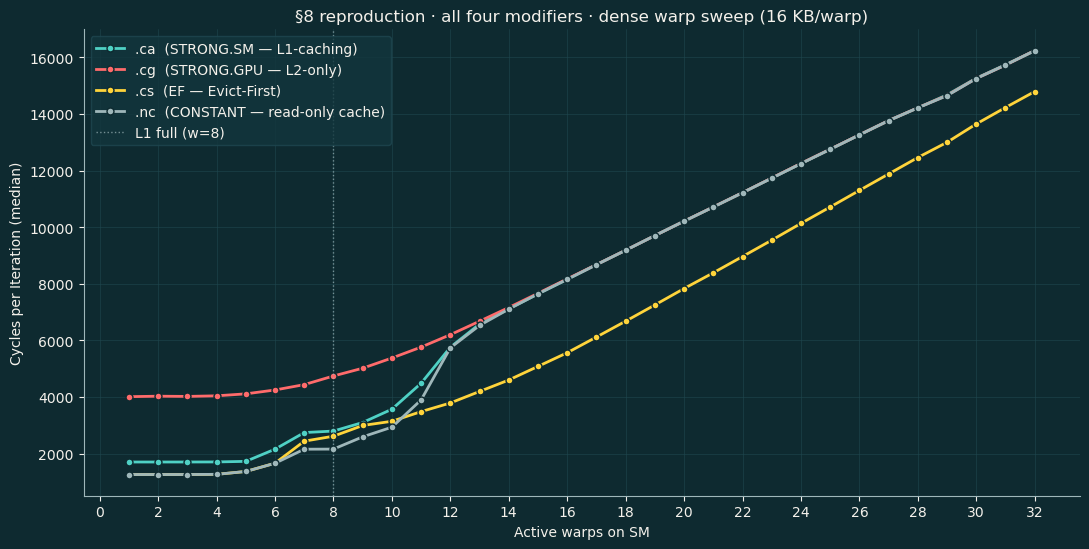


                regime     .cg/.ca     .cs/.ca     .nc/.ca
        sub-L1   (w=1)       2.36x       0.74x       0.74x
        L1-full  (w=8)       1.70x       0.93x       0.77x
    L2-resident (w=16)       1.00x       0.68x       1.00x
       max      (w=32)       1.00x       0.91x       1.00x


In [17]:
COLORS = {"ca": "#4FD1C5", "cg": "#FF6B6B", "cs": "#FFD43B", "nc": "#9FB7BA"}
LABELS = {"ca": ".ca  (STRONG.SM — L1-caching)",
          "cg": ".cg  (STRONG.GPU — L2-only)",
          "cs": ".cs  (EF — Evict-First)",
          "nc": ".nc  (CONSTANT — read-only cache)"}

fig, ax = plt.subplots(figsize=(11, 5.6))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")

for mod in MODIFIERS:
    ax.plot(WARPS_SWEEP, cycles_per_warp[mod], "o-",
            color=COLORS[mod], linewidth=2.0, markersize=5,
            markeredgecolor="#0E2A30", label=LABELS[mod])

l1_full_at = 128 // PER_WARP_KB
ax.axvline(l1_full_at, color="#9FB7BA", linestyle=":", linewidth=1.0,
           alpha=0.7, label=f"L1 full (w={l1_full_at})")

for spine in ("top", "right"):       ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):     ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.4)

ax.set_xticks(range(0, 33, 2))
ax.set_xlabel("Active warps on SM")
ax.set_ylabel("Cycles per Iteration (median)")
ax.set_title("§8 reproduction · all four modifiers · dense warp sweep "
             f"({PER_WARP_KB} KB/warp)")
leg = ax.legend(loc="upper left", facecolor="#12363D", edgecolor="#1F4750",
                labelcolor="#F4F1EB")
plt.tight_layout(); plt.show()

# Ratio table at three regime points
print(f"\n{'regime':>22}  {'.cg/.ca':>10}  {'.cs/.ca':>10}  {'.nc/.ca':>10}")
for label, nw in [("sub-L1   (w=1)",  1),
                  ("L1-full  (w=8)",  8),
                  ("L2-resident (w=16)", 16),
                  ("max      (w=32)", 32)]:
    j = WARPS_SWEEP.index(nw)
    base = cycles_per_warp["ca"][j]
    print(f"{label:>22}  "
          f"{cycles_per_warp['cg'][j]/base:>9.2f}x  "
          f"{cycles_per_warp['cs'][j]/base:>9.2f}x  "
          f"{cycles_per_warp['nc'][j]/base:>9.2f}x")


## 12. Multi-SM .cg penalty · fig_multism (slide §8)

Holds per-block warps fixed at 8 (one SM's L1 fill = 128 KB) and sweeps concurrent **blocks** from 1 to 38. `.ca`/`.cs`/`.nc` stay flat — each SM's L1 absorbs its block. `.cg` ramps sharply past full chip because every SM's L1-bypassed traffic piles onto shared L2. Slide claim: `.cg/.ca` = **1.73×** at 1 SM, **6.27×** at full chip.

SM count: 38.  Sweep concurrent blocks 1..38.

blocks       .ca       .cg       .cs       .nc   .cg/.ca
     1      2636      4748      2579      2148     1.80x
     2      2688      4760      2542      2175     1.77x
     4      2731      4818      2550      2184     1.76x
     8      2697      4781      2536      2134     1.77x
    16      2679      4872      2543      2130     1.82x
    24      2659      5186      2578      2123     1.95x
    32      2980     11002      2644      2382     3.69x
    38      3042     20556      2708      2406     6.76x


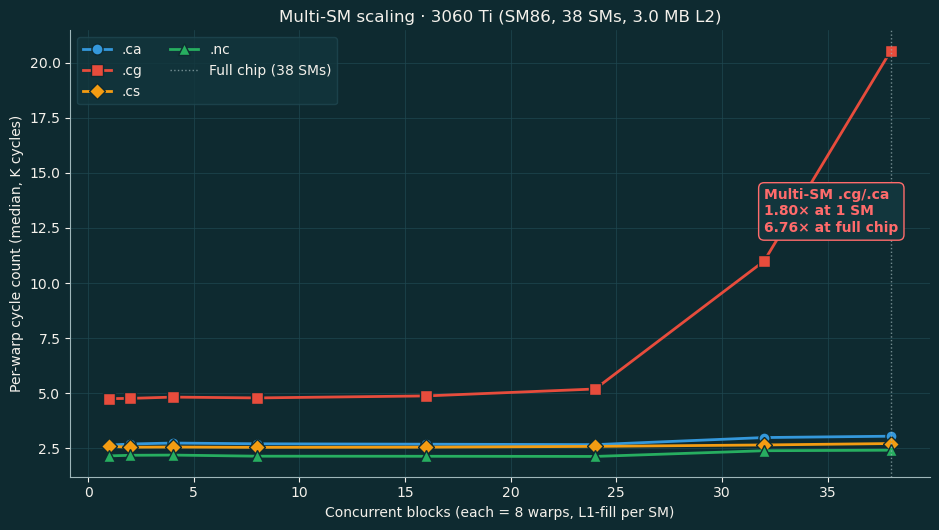


Slide claim (fig_multism, SM86): single-SM .cg/.ca = 1.73×;  full chip = 6.27×
Live demo:                       single-SM .cg/.ca = 1.80×;  full chip = 6.76×


In [18]:
# Slide §8 fig_multism reproduction.
# Fix 8 warps per block (per-SM L1 fill = 128 KB on SM86).  Sweep concurrent
# blocks from 1 to 38.  For each (modifier, num_blocks) record per-warp cycles.
# Expected shape:
#   .ca / .cs / .nc — flat (each SM's L1 absorbs its block; no inter-SM contention)
#   .cg             — flat at low block counts, ramps sharply past full chip
#                     (every SM dumps its bypassed traffic onto the shared L2)

import cupy as cp, numpy as np, matplotlib.pyplot as plt

B_RELOAD_MOD_SRC = r"""
extern "C" __global__ void b_reload_MOD(
    const float* __restrict__ B,
    long long*   __restrict__ cycles,
    float*       __restrict__ sums,
    int b_len, int reps
) {
    int warp_id = (blockIdx.x * blockDim.x + threadIdx.x) / 32;
    int lane    = threadIdx.x & 31;
    const float* my_B = B + (long long)warp_id * b_len;
    float acc = 0.f;
    for (int k = lane; k < b_len; k += 32) {
        float v;
        asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v) : "l"(my_B + k) : "memory");
        acc += v;
    }
    long long t0 = clock64();
    for (int r = 0; r < reps; r++) {
        for (int k = lane; k < b_len; k += 32) {
            float v;
            asm volatile("ld.global.MOD.f32 %0, [%1];" : "=f"(v) : "l"(my_B + k) : "memory");
            acc += v;
        }
    }
    long long t1 = clock64();
    if (lane == 0) { cycles[warp_id] = t1 - t0; sums[warp_id] = acc; }
}
"""

MODIFIERS = ["ca", "cg", "cs", "nc"]
kerns = {}
for mod in MODIFIERS:
    src = B_RELOAD_MOD_SRC.replace("MOD", mod)
    rm  = cp.RawModule(code=src, options=("--use_fast_math",))
    kerns[mod] = rm.get_function(f"b_reload_{mod}")

NW_PER_BLOCK = 8            # 8 warps × 16 KB = 128 KB = L1 capacity on SM86
B_LEN        = 4096         # 16 KB per warp
REPS         = 64
WARMUP, ITERS = 10, 20

NUM_SMS = props.multi_processor_count
print(f"SM count: {NUM_SMS}.  Sweep concurrent blocks 1..{NUM_SMS}.")

# Block-count grid — coarse enough to keep total runtime ~1 min.
block_grid = [1, 2, 4, 8, 16, 24, 32, NUM_SMS]
block_grid = sorted(set(block_grid))

def time_at(mod, num_blocks):
    B      = cp.random.randn(num_blocks * NW_PER_BLOCK * B_LEN, dtype=cp.float32)
    cycles = cp.zeros(num_blocks * NW_PER_BLOCK, dtype=cp.int64)
    sums   = cp.zeros(num_blocks * NW_PER_BLOCK, dtype=cp.float32)
    args   = (B, cycles, sums, np.int32(B_LEN), np.int32(REPS))
    for _ in range(WARMUP):
        kerns[mod]((num_blocks, 1, 1), (NW_PER_BLOCK * 32, 1, 1), args)
    cp.cuda.runtime.deviceSynchronize()
    raws = []
    for _ in range(ITERS):
        kerns[mod]((num_blocks, 1, 1), (NW_PER_BLOCK * 32, 1, 1), args)
        cp.cuda.runtime.deviceSynchronize()
        raws.append(float(np.mean(cycles.get())) / REPS)
    return float(np.median(raws))

cy_curves = {mod: [] for mod in MODIFIERS}
print(f"\n{'blocks':>6}  " + "  ".join(f"{('.'+m):>8}" for m in MODIFIERS) + f"  {'.cg/.ca':>8}")
for nb in block_grid:
    row = {mod: time_at(mod, nb) for mod in MODIFIERS}
    for mod in MODIFIERS:
        cy_curves[mod].append(row[mod])
    ratio = row["cg"] / row["ca"]
    print(f"{nb:>6}  " + "  ".join(f"{row[m]:>8.0f}" for m in MODIFIERS) + f"  {ratio:>7.2f}x")

# Plot — match slide layout
COLORS = {"ca": "#3498db", "cg": "#e74c3c", "cs": "#f39c12", "nc": "#27ae60"}
MARKERS = {"ca": "o", "cg": "s", "cs": "D", "nc": "^"}

fig, ax = plt.subplots(figsize=(9.5, 5.4))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")
for mod in MODIFIERS:
    y = [v / 1000.0 for v in cy_curves[mod]]   # K cycles
    ax.plot(block_grid, y, "-" + MARKERS[mod], color=COLORS[mod], linewidth=2.0,
            markersize=8, markeredgecolor="#0E2A30", label=f".{mod}")

# Mark the full-chip column.
ax.axvline(NUM_SMS, color="#9FB7BA", linestyle=":", linewidth=1.0,
           alpha=0.7, label=f"Full chip ({NUM_SMS} SMs)")

# Annotation box like the slide.
cg_1   = cy_curves["cg"][block_grid.index(1)]      / 1000
cg_max = cy_curves["cg"][block_grid.index(NUM_SMS)]/ 1000
ca_1   = cy_curves["ca"][block_grid.index(1)]      / 1000
ca_max = cy_curves["ca"][block_grid.index(NUM_SMS)]/ 1000
ax.annotate(
    f"Multi-SM .cg/.ca\n{cg_1/ca_1:.2f}× at 1 SM\n{cg_max/ca_max:.2f}× at full chip",
    xy=(NUM_SMS - 6, cg_max * 0.6),
    color="#FF6B6B", fontsize=10, weight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc="#12363D", ec="#FF6B6B", lw=1.0),
)

for spine in ("top", "right"):    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):  ax.spines[spine].set_color("#9FB7BA")
ax.tick_params(colors="#F4F1EB")
ax.xaxis.label.set_color("#F4F1EB"); ax.yaxis.label.set_color("#F4F1EB")
ax.title.set_color("#F4F1EB")
ax.grid(True, color="#1F4750", linewidth=0.5)

ax.set_xlabel("Concurrent blocks (each = 8 warps, L1-fill per SM)")
ax.set_ylabel("Per-warp cycle count (median, K cycles)")
ax.set_title(f"Multi-SM scaling · {props.name.split()[-2]} {props.name.split()[-1]} "
             f"(SM{props.major}{props.minor}, {NUM_SMS} SMs, {props.L2_cache_size/1024**2:.1f} MB L2)")
ax.legend(loc="upper left", facecolor="#12363D", edgecolor="#1F4750", labelcolor="#F4F1EB", ncol=2)
plt.tight_layout(); plt.show()

print(f"\nSlide claim (fig_multism, SM86): single-SM .cg/.ca = 1.73×;  full chip = 6.27×")
print(f"Live demo:                       single-SM .cg/.ca = {cg_1/ca_1:.2f}×;  full chip = {cg_max/ca_max:.2f}×")


## 13. Decision map · WS × num_warps → bandwidth (slide §11 · s10_landscape)

2-D cost map. Slide claim: peak ~ 6485 GB/s at `nw=8, WS=64 KB`; 6.4× spread.

WS =      4 KB   nw1= 1400  nw2= 1769  nw4= 1785  nw8= 1714  nw16= 1777  nw32= 1206
WS =      8 KB   nw1= 3586  nw2= 3608  nw4= 3586  nw8= 3636  nw16= 3191  nw32= 1922
WS =     16 KB   nw1= 4910  nw2= 6301  nw4= 5647  nw8= 5705  nw16= 4022  nw32= 2418
WS =     32 KB   nw1= 5352  nw2= 6872  nw4= 6503  nw8= 6918  nw16= 4887  nw32= 2970
WS =     64 KB   nw1= 5574  nw2= 7265  nw4= 7083  nw8= 7699  nw16= 5353  nw32= 3342
WS =    128 KB   nw1= 2458  nw2= 2895  nw4= 6827  nw8= 7443  nw16= 5471  nw32= 3492
WS =    256 KB   nw1= 2386  nw2= 2790  nw4= 5071  nw8= 5181  nw16= 3078  nw32= 1480


WS =    512 KB   nw1= 2391  nw2= 2893  nw4= 5321  nw8= 5383  nw16= 2823  nw32= 1395


WS =   1024 KB   nw1= 2449  nw2= 2920  nw4= 5354  nw8= 4949  nw16= 2591  nw32= 1380


WS =   2048 KB   nw1= 2501  nw2= 2942  nw4= 5107  nw8= 4759  nw16= 2806  nw32= 1393


WS =   3072 KB   nw1= 1939  nw2= 2287  nw4= 4221  nw8= 4936  nw16= 2825  nw32= 1371


WS =   4096 KB   nw1= 1446  nw2= 1643  nw4= 3207  nw8= 4782  nw16= 2831  nw32= 1261


WS =   8192 KB   nw1= 1447  nw2= 1643  nw4= 3163  nw8= 4625  nw16= 2738  nw32= 1239


WS =  16384 KB   nw1= 1442  nw2= 1640  nw4= 3157  nw8= 4560  nw16= 2666  nw32= 1216


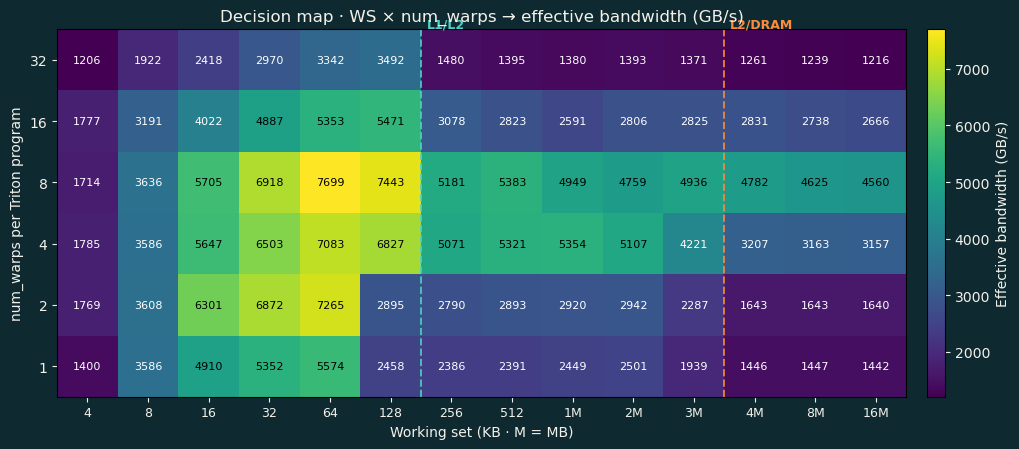


best  : nw= 8, WS=   64 KB  →   7699 GB/s
worst : nw=32, WS=    4 KB  →   1206 GB/s
spread: 6.38× across the (warps, WS) plane (slide claim: 6.4×, peak ~6485 GB/s at nw=8, WS=64 KB)


In [19]:
# Slide §11 figure s10_landscape.png: WS × num_warps -> bandwidth heatmap.
# Slide claim: peak ~6485 GB/s at nw=8, WS=64 KB; 6.4x spread across the grid.

ws_kb_2d = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 3072, 4096, 8192, 16384]
warp_2d  = [1, 2, 4, 8, 16, 32]

bw_2d = np.zeros((len(warp_2d), len(ws_kb_2d)), dtype=np.float64)
for j, kb in enumerate(ws_kb_2d):
    row_txt = []
    for i, nw in enumerate(warp_2d):
        _ms, gbs = time_at_warps(nw, kb * 1024, reps=10, warmup=3)
        bw_2d[i, j] = gbs
        row_txt.append(f"nw{nw}={gbs:>5.0f}")
    print(f"WS = {kb:>6} KB   " + "  ".join(row_txt))

# Heatmap
fig, ax = plt.subplots(figsize=(11, 4.6))
fig.patch.set_facecolor("#0E2A30"); ax.set_facecolor("#0E2A30")
im = ax.imshow(bw_2d, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")

ax.set_xticks(range(len(ws_kb_2d)))
ax.set_xticklabels([f"{kb}" if kb < 1024 else f"{kb//1024}M" for kb in ws_kb_2d], fontsize=9)
ax.set_yticks(range(len(warp_2d))); ax.set_yticklabels(warp_2d)
ax.tick_params(colors="#F4F1EB")
ax.set_xlabel("Working set (KB · M = MB)",    color="#F4F1EB")
ax.set_ylabel("num_warps per Triton program", color="#F4F1EB")
ax.set_title("Decision map · WS × num_warps → effective bandwidth (GB/s)",
             color="#F4F1EB")

vmax = np.nanmax(bw_2d)
for i in range(bw_2d.shape[0]):
    for j in range(bw_2d.shape[1]):
        v = bw_2d[i, j]
        if np.isnan(v): continue
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                color="white" if v < vmax * 0.55 else "black", fontsize=8)

# Tier boundaries: L1 ends at 128 KB; L2 ends at 3 MB.
def col_of(kb_target):
    for idx, k in enumerate(ws_kb_2d):
        if k > kb_target: return idx - 0.5
    return len(ws_kb_2d) - 0.5
ax.axvline(col_of(128),  color="#4FD1C5", linewidth=1.4, linestyle="--", alpha=0.85)
ax.axvline(col_of(3072), color="#FF8A3D", linewidth=1.4, linestyle="--", alpha=0.85)
ax.text(col_of(128)  + 0.1, len(warp_2d) - 0.3, "L1/L2",
        color="#4FD1C5", fontsize=9, ha="left", va="top", weight="bold")
ax.text(col_of(3072) + 0.1, len(warp_2d) - 0.3, "L2/DRAM",
        color="#FF8A3D", fontsize=9, ha="left", va="top", weight="bold")

cb = fig.colorbar(im, ax=ax, pad=0.02)
cb.set_label("Effective bandwidth (GB/s)", color="#F4F1EB")
cb.ax.yaxis.set_tick_params(color="#F4F1EB")
plt.setp(cb.ax.get_yticklabels(), color="#F4F1EB")
plt.tight_layout(); plt.show()

best  = np.unravel_index(np.nanargmax(bw_2d), bw_2d.shape)
worst = np.unravel_index(np.nanargmin(bw_2d), bw_2d.shape)
print()
print(f"best  : nw={warp_2d[best[0]]:>2}, WS={ws_kb_2d[best[1]]:>5} KB  →  {bw_2d[best]:>5.0f} GB/s")
print(f"worst : nw={warp_2d[worst[0]]:>2}, WS={ws_kb_2d[worst[1]]:>5} KB  →  {bw_2d[worst]:>5.0f} GB/s")
print(f"spread: {bw_2d[best] / bw_2d[worst]:.2f}× across the (warps, WS) plane "
      f"(slide claim: 6.4×, peak ~6485 GB/s at nw=8, WS=64 KB)")


## 14. Per-tier plateau recap (slide R3 echo)


In [20]:
def plateau(items, lo_kb, hi_kb):
    return float(np.median([gbs for kb, (_ms, gbs) in items if lo_kb <= kb <= hi_kb]))

items = list(results.items())
bw_l1   = plateau(items,    64,   128)   # L1-resident regime (per-SM 128 KB on SM86)
bw_l2   = plateau(items,   256,  2048)   # L2-resident regime (3 MB L2 on 3060 Ti)
bw_dram = plateau(items,  6144, 16384)   # DRAM regime

print(f"L1   plateau  ≈ {bw_l1:>6.0f} GB/s")
print(f"L2   plateau  ≈ {bw_l2:>6.0f} GB/s   ({bw_l1/bw_l2:.2f}× L1 BW)")
print(f"DRAM plateau  ≈ {bw_dram:>6.0f} GB/s   ({bw_l1/bw_dram:.2f}× L1 BW)")
print()
print("The Triton kernel never picks a cache modifier. The hierarchy is visible")
print("anyway · because the working set decides which tier serves the load.")


L1   plateau  ≈   6074 GB/s
L2   plateau  ≈   4545 GB/s   (1.34× L1 BW)
DRAM plateau  ≈   3169 GB/s   (1.92× L1 BW)

The Triton kernel never picks a cache modifier. The hierarchy is visible
anyway · because the working set decides which tier serves the load.
